In [1]:
import jax
print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX devices: [CudaDevice(id=0)]
Default backend: gpu


W1119 12:42:04.754099    1567 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1119 12:42:04.762485    1465 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [23]:
# Enable autoreload of local Python modules (e.g., models)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time

# local imports
import models.models1 as models
import util.generation as generation


In [25]:
# initialize the jax random key
key = jax.random.key(0)

# Load data

In [26]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("./data/text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [27]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [28]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [29]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

scal year calendar year notes unidad de planeaci n minero energ tica upme two zero zero four bolet n estad stico de minas y ener

 such as a lastnode variable which points to some node in the list or is null if it s empty we use such a lastnode here this rep

 king of bohemia sought to restore the imperial authority around the middle of the one four th century the black death ravaged g

lberto ran to the horse threw his arms up around the horse s neck to protect it and collapsed to the ground in the following few

he federal army developing a truly effective cavalry force fighting as mounted infantry asia in eastern europe russia and out on



# Create a basic Transformer model

In [56]:
def create_train_state(
    rng,
    vocab_size=27,
    d_model=64,
    n_layers=6,
    n_heads=8,
    max_len=128,
    dropout=0.1,
):
    # create a basic Transformer model
    model = models.DecoderOnlyTransformer(
        vocab_size=vocab_size,
        d_model=d_model,
        n_layers=n_layers,
        n_heads=n_heads,
        n_kv_heads=1,     # explicit, you can change if you want GQA
        max_len=max_len,
        dropout=dropout,
    )
    # create a dummy input for initialization
    dummy = jnp.zeros((1, min(16, max_len)), dtype=jnp.int32)
    # pass the dummy input to the model to initialize the parameters
    params = model.init({"params": rng}, dummy)["params"]
    return model, params


In [ ]:
# # vocab size
# vocab_size= len(char_set)

# # internal model dimensions
# d_model=256

# # number of attention heads
# n_heads=8

# # number of Transformer layers
# n_layers=2

# # maximum sequence length
# max_len=128

# model, params = create_train_state(key, vocab_size, d_model, n_layers, n_heads, max_len)

In [13]:
# # compute the number of parameters
# def count_params(params):
#     return sum(x.size for x in jax.tree_util.tree_leaves(params))
# print(f"Number of parameters: {count_params(params):_}")

Number of parameters: 1_350_658


In [49]:
# sanity check: create a batch of data & run a forward pass
B, T = 4, 32
batch = jax.random.randint(
    key=key,
    shape=(B, T), minval=0, maxval=len(char_set))
logits = model.apply({"params": params}, batch)

print("batch shape:", batch.shape)  # (B, T)
print("logits shape:", logits.shape)  # (B, T, vocab_size)

batch shape: (4, 32)
logits shape: (4, 32, 27)


# Loss function

In [50]:
@jax.jit
def loss_and_metrics(logits, targets):
    """Compute cross-entropy loss and accuracy.

    Assumes `targets` contains only valid integer class ids in [0, V-1] (no -1 ignore tokens).

    Args:
      logits: (B, T, V) float array of unnormalized scores.
      targets: (B, T) integer array with ground-truth class ids.

    Returns:
      loss: scalar average cross-entropy over all positions.
      metrics: dict with keys "loss" and "acc" (both scalars).
    """
    # Flatten batch/time dims so optax works on shape (N, V) and (N,)
    vocab = logits.shape[-1]
    flat_logits = logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)

    # Per-position cross-entropy, then mean over all positions
    per_pos = optax.softmax_cross_entropy_with_integer_labels(flat_logits, flat_targets)
    loss = per_pos.mean()

    # prediction over all positions
    preds = jnp.argmax(logits, axis=-1)  # (B, T)
    
    # compute accuracy over only the last position
    is_match = preds == targets
    
    # Accuracy over all positions
    acc_all = jnp.mean(is_match.astype(jnp.float32))
    
    # Accuracy over only last position
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:,-1])

    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}

# Optimization step:

In [51]:
# create an update function
def train_step(params, opt_state, x, y, tx):
    """Single optimization step using optax optimizer.

    Args:
      params: pytree of model parameters.
      opt_state: optax optimizer state corresponding to `params`.
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
      tx: optax.GradientTransformation (already initialized).

    Returns:
      new_params: updated parameters after one gradient step.
      new_opt_state: updated optimizer state.
      metrics: dict of scalar metrics (loss, acc).
    """
    def loss_fn(params):
        logits = model.apply({"params": params}, x)
        loss, metrics = loss_and_metrics(logits, y)
        return loss, metrics

    # compute gradients (loss is scalar, metrics is auxiliary)
    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # optax update: compute parameter updates and new optimizer state
    updates, new_opt_state = tx.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, metrics

# jit: last argument should be static because it is an object
train_step = jax.jit(train_step, static_argnames=("tx",))

# Batch creation:

In [52]:
# create a batch from the training data
def get_batch(text_int, B, T):
    """Create a random batch of data from text_int.

    Args:
      text_int: 1D array of token ids.
      B: batch size (number of sequences).
      T: sequence length (number of tokens per sequence).

    Returns:
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
    """
    # choose random starting indices for each sequence in the batch
    ix = np.random.randint(0, len(text_int) - T, size=B)
    # inputs are text from i to i+T
    x = np.stack([text_int[i:i+T] for i in ix])
    # targets are text from i+1 to i+T+1
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

In [53]:
def run_single_config(
    config,
    train_text_int,
    test_text_int,
    base_key,
    niter_search=1000,
    B=128,
    B_test=512,
    eval_every=200,
):
    print("\n=== Running config:", config, "===\n")

    T = config["T"]
    T_test = config["T"]

    key_init, key_train = jax.random.split(base_key)

    model, params = create_train_state(
        key_init,
        vocab_size=config["vocab_size"],
        d_model=config["d_model"],
        n_layers=config["n_layers"],
        n_heads=config["n_heads"],
        max_len=config["max_len"],   # keep ≥ max T
        dropout=config["dropout"],
    )

    if config["opt"] == "adamw":
        lr = config["learning_rate"]
        tx = optax.adamw(learning_rate=lr, weight_decay=config["weight_decay"])
    else:
        lr = config["learning_rate"]
        tx = optax.adam(learning_rate=lr)

    opt_state = tx.init(params)

    @jax.jit
    def train_step_local(params, opt_state, x, y):
        def loss_fn(p):
            logits = model.apply({"params": p}, x)
            loss, metrics = loss_and_metrics(logits, y)
            return loss, metrics

        (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        updates, new_opt_state = tx.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, metrics

    best_test_loss = None

    for it in range(1, niter_search + 1):
        # training batch with per-config T
        x, y = get_batch(train_text_int, B, T)
        params, opt_state, metrics = train_step_local(params, opt_state, x, y)

        if it % eval_every == 0 or it == niter_search:
            x_test, y_test = get_batch(test_text_int, B_test, T_test)
            logits_test = model.apply({"params": params}, x_test)
            test_loss, test_metrics = loss_and_metrics(logits_test, y_test)

            test_loss_val = float(test_loss)
            acc_last = float(metrics["acc_last"])
            test_acc_last = float(test_metrics["acc_last"])

            print(
                f"[it {it:5d}] "
                f"T={T:3d} "
                f"train_loss={float(metrics['loss']):.4f} "
                f"test_loss={test_loss_val:.4f} "
                f"train_acc_last={100*acc_last:.1f}% "
                f"test_acc_last={100*test_acc_last:.1f}%"
            )

            if best_test_loss is None or test_loss_val < best_test_loss:
                best_test_loss = test_loss_val

    return best_test_loss, params, model


In [55]:
# ---- hyperparameter search space ----

model_configs = [
    {"d_model": 256, "n_layers": 2, "n_heads": 8},
    {"d_model": 384, "n_layers": 4, "n_heads": 8},
]

dropouts = [0.0, 0.1]
learning_rates = [1e-3, 3e-4]
opts = ["adam", "adamw"]
weight_decays = [1e-2]
T_values = [32, 64]

search_space = []

for mc in model_configs:
    for T in T_values: 
        for drop in dropouts:
            for lr in learning_rates:
                for opt in opts:
                    if opt == "adam":
                        cfg = {
                            "vocab_size": vocab_size,
                            "max_len": max_len,
                            "d_model": mc["d_model"],
                            "n_layers": mc["n_layers"],
                            "n_heads": mc["n_heads"],
                            "dropout": drop,
                            "learning_rate": lr,
                            "opt": "adam",
                            "weight_decay": 0.0,
                            "T": T, 
                        }
                        search_space.append(cfg)
                    else:
                        for wd in weight_decays:
                            cfg = {
                                "vocab_size": vocab_size,
                                "max_len": max_len,
                                "d_model": mc["d_model"],
                                "n_layers": mc["n_layers"],
                                "n_heads": mc["n_heads"],
                                "dropout": drop,
                                "learning_rate": lr,
                                "opt": "adamw",
                                "weight_decay": wd,
                                "T": T,
                            }
                            search_space.append(cfg)

print("Total configs in search space:", len(search_space))


Total configs in search space: 32


In [58]:
best_config = None
best_loss = None
best_model = None
best_params = None

base_key = jax.random.PRNGKey(0)

for i, config in enumerate(search_space):
    print(f"\n##### Config {i+1}/{len(search_space)} #####")
    key_i = jax.random.fold_in(base_key, i)

    test_loss, params_cfg, model_cfg = run_single_config(
        config,
        train_text_int=train_text_int,
        test_text_int=test_text_int,
        base_key=key_i,
        niter_search=1000,
        B=128,
        B_test=512,
        eval_every=200,
    )

    print(f"Config {i+1} finished with best_test_loss={test_loss:.4f}")

    if best_loss is None or test_loss < best_loss:
        best_loss = test_loss
        best_config = config
        best_model = model_cfg
        best_params = params_cfg

print("\n=== GRID SEARCH DONE ===")
print("Best config:", best_config)
print("Best validation loss:", best_loss)


##### Config 1/32 #####

=== Running config: {'vocab_size': 27, 'max_len': 128, 'd_model': 256, 'n_layers': 2, 'n_heads': 8, 'dropout': 0.0, 'learning_rate': 0.001, 'opt': 'adam', 'weight_decay': 0.0, 'T': 32} ===

[it   200] T= 32 train_loss=2.0218 test_loss=2.0291 train_acc_last=35.2% test_acc_last=39.1%
[it   400] T= 32 train_loss=1.7303 test_loss=1.7340 train_acc_last=44.5% test_acc_last=46.1%
[it   600] T= 32 train_loss=1.6196 test_loss=1.6319 train_acc_last=57.8% test_acc_last=53.5%
[it   800] T= 32 train_loss=1.5840 test_loss=1.5819 train_acc_last=53.9% test_acc_last=50.8%
[it  1000] T= 32 train_loss=1.5702 test_loss=1.5808 train_acc_last=47.7% test_acc_last=52.5%
Config 1 finished with best_test_loss=1.5808

##### Config 2/32 #####

=== Running config: {'vocab_size': 27, 'max_len': 128, 'd_model': 256, 'n_layers': 2, 'n_heads': 8, 'dropout': 0.0, 'learning_rate': 0.001, 'opt': 'adamw', 'weight_decay': 0.01, 'T': 32} ===

[it   200] T= 32 train_loss=2.0167 test_loss=2.0237 trai

In [59]:
print("\nUsing best config for full training:", best_config)

d_model = best_config["d_model"]
n_layers = best_config["n_layers"]
n_heads = best_config["n_heads"]
dropout = best_config["dropout"]
learning_rate = best_config["learning_rate"]
opt_type = best_config["opt"]
weight_decay = best_config["weight_decay"]
T = best_config["T"]

total_steps = 15000

# new RNG for final training
key = jax.random.PRNGKey(42)
model, params = create_train_state(
    key,
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    max_len=max_len,
    dropout=dropout,
)

# count final params (optional)
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters (best config): {count_params(params):_}")

# --------------------------------------------------
# Cosine learning rate schedule for FINAL RUN
# --------------------------------------------------
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=learning_rate,
    warmup_steps=1_000,
    decay_steps=total_steps,
    end_value=0.1 * learning_rate
)

# optimizer for final run, using the schedule
if opt_type == "adamw":
    tx = optax.adamw(learning_rate=schedule, weight_decay=weight_decay)
else:
    tx = optax.adam(learning_rate=schedule)

opt_state = tx.init(params)
print(f"Initialized optimizer: {opt_type} with cosine LR schedule (peak lr={learning_rate})")



Using best config for full training: {'vocab_size': 27, 'max_len': 128, 'd_model': 384, 'n_layers': 4, 'n_heads': 8, 'dropout': 0.1, 'learning_rate': 0.001, 'opt': 'adamw', 'weight_decay': 0.01, 'T': 64}
Number of parameters (best config): 6_059_524
Initialized optimizer: adamw with cosine LR schedule (peak lr=0.001)


# Optimizer creation:

In [ ]:
# # define optax optimizer
# learning_rate = 0.001
# # Create Adam optimizer (Optax)
# tx = optax.adam(learning_rate=learning_rate)
# # Initialize optimizer state for current params
# opt_state = tx.init(params)
# print(f"Initialized optimizer: Adam lr={learning_rate}")

In [60]:
niter = total_steps 
B = 128
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()

iteration 0  time: 3.9 seconds
	 	 loss(train :: test): 18.2335 :: 18.0952
	 	 accuracy (train :: test): 1.1% :: 1.5%
	 	 accuracy (last character) (train :: test): 1.6% :: 2.0%

iteration 300  time: 31.1 seconds
	 	 loss(train :: test): 2.0017 :: 2.0496
	 	 accuracy (train :: test): 39.6% :: 37.9%
	 	 accuracy (last character) (train :: test): 33.6% :: 38.8%

iteration 600  time: 58.8 seconds
	 	 loss(train :: test): 1.6093 :: 1.5961
	 	 accuracy (train :: test): 51.0% :: 51.2%
	 	 accuracy (last character) (train :: test): 53.1% :: 54.5%

iteration 900  time: 86.4 seconds
	 	 loss(train :: test): 1.4694 :: 1.5224
	 	 accuracy (train :: test): 53.5% :: 52.9%
	 	 accuracy (last character) (train :: test): 55.5% :: 60.0%

iteration 1_200  time: 114.1 seconds
	 	 loss(train :: test): 1.4383 :: 1.4539
	 	 accuracy (train :: test): 55.2% :: 54.8%
	 	 accuracy (last character) (train :: test): 62.5% :: 60.1%

iteration 1_500  time: 141.9 seconds
	 	 loss(train :: test): 1.3521 :: 1.4495
	 	

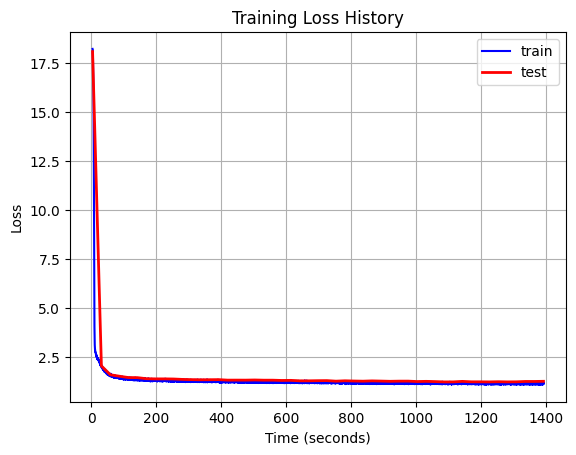

In [61]:
# plot the loss history
import matplotlib.pyplot as plt
plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

In [62]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
prompt_int = jnp.array([ [char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generation.generate_tokens(model, params, rng, prompt_int, gen_len, block_size=64, 
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 1000)
generated text:
hello my friend shelter alexander king of the battle of north east of the next zero zero years later their commanders the second driver skirt and gave the border in a section of the series responds to the first modern times of the art of french military service scored argentina for the european union cabri s first home of the king the senate in the state of probe s insect manner consists of a story or director to the modern editor for him she was almost clearly recorded in many times of the popular achievements in the monitor no string the possibility of that if the internet university has been recognized by some serious districts and a decision expressing a one zero zero zero zero zero zero zero light three four one nine two one one nine eight two four was a popular garbage arrangement company was a cross and the concept of the flag of hypertext the more details of memory than larger size of the entrepreneurial with a woman in november on